# 🖼️ 第1步：认识 CIFAR-100 数据集 & 理解 Tensor（张量）

## 本 Notebook 的学习目标

| 序号 | 知识点 | 要搞懂什么 |
|------|--------|-----------|
| ① | **CIFAR-100 数据集** | 里面有什么？图片多大？多少类别？ |
| ② | **Tensor（张量）** | PyTorch 最核心的数据结构，长什么样？ |
| ③ | **归一化（Normalization）** | 为什么要做？不做会怎样？ |
| ④ | **ImageFolder** | 如何加载本地按类分文件夹的数据？ |
| ⑤ | **DataLoader** | 批处理、打乱、多线程加载是什么？ |
| ⑥ | **可视化** | 把图片从数字矩阵画出来看 |

> 💡 **使用方法**：按 `Shift + Enter` 逐个 cell 执行，观察每一步的输出。

---
## Cell 1：导入工具库

| 库名 | 作用 |
|------|------|
| `torch` | PyTorch 核心——提供 Tensor、自动求导、GPU 运算 |
| `torchvision` | PyTorch 的视觉工具箱——包含数据集、预处理、预训练模型 |
| `torchvision.transforms` | 数据预处理——归一化、裁剪、翻转等 |
| `matplotlib.pyplot` | Python 最常用的画图库 |
| `numpy` | 数值计算库——Tensor 的好兄弟，两者可以互相转换 |
| `os` | 操作系统接口——处理文件路径 |

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import Counter

# 检查 PyTorch 版本和 MPS（Apple 芯片 GPU 加速）是否可用
print(f"PyTorch 版本: {torch.__version__}")
print(f"MPS (Apple GPU) 可用: {torch.backends.mps.is_available()}")

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Heiti TC', 'PingFang HK']
plt.rcParams['axes.unicode_minus'] = False

PyTorch 版本: 2.8.0
MPS (Apple GPU) 可用: True


---
## Cell 2：定义数据预处理（transforms）

### 🤔 为什么需要 transforms？

原始图片的像素值是 **0-255 的整数**。如果直接喂给神经网络：
- 数值太大 → 梯度爆炸或不稳定
- 不同图片亮度差异大 → 模型难以学习共同模式

### 归一化两步走

```
原始图片 [0-255 整数]
    ↓ ToTensor()   → 除以 255
张量   [0.0-1.0 浮点数]
    ↓ Normalize()  → (x - mean) / std
标准化 [-1.0-1.0 浮点数]
```

这里 `mean=0.5, std=0.5` 等价于把 [0,1] 映射到 [-1,1]：
> (0 - 0.5) / 0.5 = **-1**  (1 - 0.5) / 0.5 = **+1**

In [2]:
# Compose 把多个处理步骤串联成一个管道
transform = transforms.Compose([
    transforms.ToTensor(),          # 步骤①：PIL图片 → Tensor，同时把 0-255 变成 0.0-1.0
    transforms.Normalize(           # 步骤②：标准化
        mean=(0.5, 0.5, 0.5),      #   RGB 三个通道各自的均值
        std=(0.5, 0.5, 0.5)        #   RGB 三个通道各自的标准差
    )
])
print("✅ transform 定义好了，它会在每张图片被读取时自动执行")

✅ transform 定义好了，它会在每张图片被读取时自动执行


---
## Cell 3：加载 CIFAR-100 本地数据集

### CIFAR-100 是什么？

CIFAR-100 和 CIFAR-10 是"亲兄弟"：

```
总图片数：60,000 张（和 CIFAR-10 一样多）
每张图片：32×32 像素 × RGB 3通道（和 CIFAR-10 一样大）
区别：   100 个类别（比 CIFAR-10 多 10 倍！）

每类只有 600 张（500 训练 + 100 测试）
  → 比 CIFAR-10 难得多：类多、每类样本少
  → 更能看出 CNN 的真实能力
```

### 100 个类别（部分示例）

```
乌龟、云、仓鼠、兔子、公交车、兰花、割草机、台灯、
向日葵、坦克、城堡、大海、大象、女人、女孩、婴儿、
山、平原、床、恐龙... 共 100 类
```

### 用 ImageFolder 加载本地数据

你已经有现成的 CIFAR-100 数据在 `./CIFAR-100数据集/` 下。
`ImageFolder` 专门处理"按类分文件夹"的数据集——中文文件夹名完全没问题。
它会按拼音排序后自动编号：0=乌龟, 1=云, 2=仓鼠...

In [13]:
# 数据集路径（你的 CIFAR-100 数据放在这里）
data_root = './CIFAR-100数据集/CIFAR-100数据集'

# ImageFolder 扫描所有子文件夹，每个子文件夹 = 一个类别
# 中文文件夹名完全没问题，会自动按拼音排序编号
full_dataset = ImageFolder(root=data_root, transform=transform)  #以imagefolder的方式读取数据集
print(f"{full_dataset[0]=}") #返回的是（第0张图片代表的三阶tensor，label） 每张图片都是C*H*W的三阶tensor形状

print(f"📦 数据集总览：")
print(f"   总图片数: {len(full_dataset)} 张")
print(f"   类别数:   {len(full_dataset.classes)} 个")  #.classes方法表示类别组成的列表，属于统计
print(f"   前5个类别 (编号0-4):  {full_dataset.classes[:5]}") #类别名为中文
print(f"   后5个类别 (编号95-99): {full_dataset.classes[-5:]}")
print()

# ============================================================
# 拆分训练集/测试集（每类 500 训练 + 100 测试）
#
# 为什么手动拆？因为数据没有分 train/test 目录，
# ImageFolder 只能整体加载，需要自己分层抽样。
# ============================================================
targets = full_dataset.targets  # 每张图的类别编号列表   .targets方法输出的是类别编号
print(f"前十张图片的类别为： {targets[:10]}")
print(f"后十张图片的类别编号为： {targets[-10:]}")

train_indices = []
test_indices = []

for class_idx in range(100):
    # 找到该类别的所有图片索引
    class_indices = [i for i, t in enumerate(targets) if t == class_idx]   #将等于class_idx类别编号的索引保存
    train_indices.extend(class_indices[:500])  # 前500张→训练。extend方法是拆开列表再逐个放入，而append是添加一个
    test_indices.extend(class_indices[500:])    # 后100张→测试

# Subset：不复制数据，只记录索引的"视图" 即subset作为pytorch的处理工具，只记录train_indices包含索引对应的full_dataset位置，而不创建新数组
train_dataset = Subset(full_dataset, train_indices)
test_dataset = Subset(full_dataset, test_indices)

# 记下类别名（后面 cell 要用）
class_names = full_dataset.classes

print(f"📊 拆分后：")
print(f"   训练集: {len(train_dataset)} 张 (100类 × 500张)")
print(f"   测试集: {len(test_dataset)} 张 (100类 × 100张)")

# 验证每类数量是否均衡
train_labels = [full_dataset.targets[i] for i in train_indices]
test_labels = [full_dataset.targets[i] for i in test_indices]
print(f"{train_labels[0]},{train_labels[500]}")
print(f"   训练集每类: {min(Counter(train_labels).values())}~{max(Counter(train_labels).values())} 张 ✅")
print(f"   测试集每类: {min(Counter(test_labels).values())}~{max(Counter(test_labels).values())} 张 ✅")
print(f"\n✅ 数据加载完成！100个类别已就绪，无需等待下载")

full_dataset[0]=(tensor([[[-0.7725, -0.8510, -0.5686,  ..., -0.9922, -0.9765, -0.9686],
         [-0.7412, -0.7569, -0.7098,  ..., -1.0000, -0.9843, -0.9765],
         [-0.6549, -0.7490, -0.6314,  ..., -1.0000, -1.0000, -0.9922],
         ...,
         [-0.4588, -0.4353, -0.2706,  ..., -0.6706, -0.7961, -1.0000],
         [-0.5294, -0.6235, -0.3882,  ..., -0.5843, -0.6706, -0.8431],
         [-0.5922, -0.5216, -0.3176,  ..., -0.5843, -0.6549, -0.6627]],

        [[-0.8431, -0.9294, -0.7098,  ..., -0.5529, -0.5686, -0.5765],
         [-0.8196, -0.8588, -0.8588,  ..., -0.5608, -0.5765, -0.5843],
         [-0.7647, -0.8824, -0.8196,  ..., -0.5608, -0.5765, -0.5843],
         ...,
         [ 0.3569,  0.3569,  0.4588,  ...,  0.0431, -0.0431, -0.2784],
         [ 0.1686,  0.1137,  0.4039,  ...,  0.3961,  0.3333,  0.1765],
         [ 0.0588,  0.2000,  0.4980,  ...,  0.5373,  0.4667,  0.4745]],

        [[-0.8980, -1.0000, -0.8039,  ...,  0.3961,  0.3725,  0.3725],
         [-0.8902, -0.9294, 

---
## Cell 4：解剖一张图片 —— 理解 Tensor

### 🔑 Tensor 是深度学习里最重要的概念

Tensor = **多维数组** + **GPU 加速** + **自动求导**

```
维度的称呼：
  标量: torch.tensor(3.0)           → shape []            （0维）
  向量: torch.tensor([1, 2, 3])     → shape [3]           （1维）
  矩阵: torch.randn(3, 4)           → shape [3, 4]        （2维）
  图像: torch.randn(64, 3, 32, 32)  → shape [64, 3, 32, 32]（4维）
        ↑   ↑  ↑   ↑
        |   |  |   └── 宽度 W（像素列数）
        |   |  └────── 高度 H（像素行数）
        |   └───────── 通道 C（RGB=3）
        └───────────── 批次大小 B（一次处理多少张）
```

**图像数据的 shape 惯例是 [B, C, H, W]** —— 后面会反复出现。
**可以以文件夹的方式来记忆**

In [15]:
# 取训练集第一张图片
image, label = train_dataset[0] #imagefolder返回三阶tensor和label

print(f"图片 Tensor 的 shape: {image.shape}")
print(f"  维度解读: [通道数={image.shape[0]}, 高度={image.shape[1]}, 宽度={image.shape[2]}]")
print(f"  → 这是一张 {image.shape[1]}×{image.shape[2]} 的 RGB 彩色图")
print()
print(f"标签编号: {label}")
print(f"  对应的类别名: {class_names[label]}")#前面.class方法返回类别中文名，利用label标签编号来找到对应类别名
print()
print(f"Tensor 的数据类型: {image.dtype}")       # 浮点类型
print(f"Tensor 所在的设备: {image.device}")       # 默认 CPU
print()
print(f"像素值统计（归一化后）:")
print(f"  最小值: {image.min().item():.4f}")     # 约 -1
print(f"  最大值: {image.max().item():.4f}")     # 约 +1
print(f"  均值:   {image.mean().item():.4f}")    # 约 0
print(f"  标准差: {image.std().item():.4f}")     # 约 1

图片 Tensor 的 shape: torch.Size([3, 32, 32])
  维度解读: [通道数=3, 高度=32, 宽度=32]
  → 这是一张 32×32 的 RGB 彩色图

标签编号: 0
  对应的类别名: 乌龟

Tensor 的数据类型: torch.float32
Tensor 所在的设备: cpu

像素值统计（归一化后）:
  最小值: -1.0000
  最大值: 0.9608
  均值:   -0.2841
  标准差: 0.4995


---
## Cell 5：可视化 —— 把数字矩阵"画"出来

这是深度学习工程师的日常——**训练模型前一定要先看数据**。

画图前需要**反归一化**：
```
训练时的处理：原始图片 → normalize → [-1, 1]
画图时的还原：[-1, 1] → 反归一化 → [0, 1]
公式：(img × std) + mean = img × 0.5 + 0.5
```

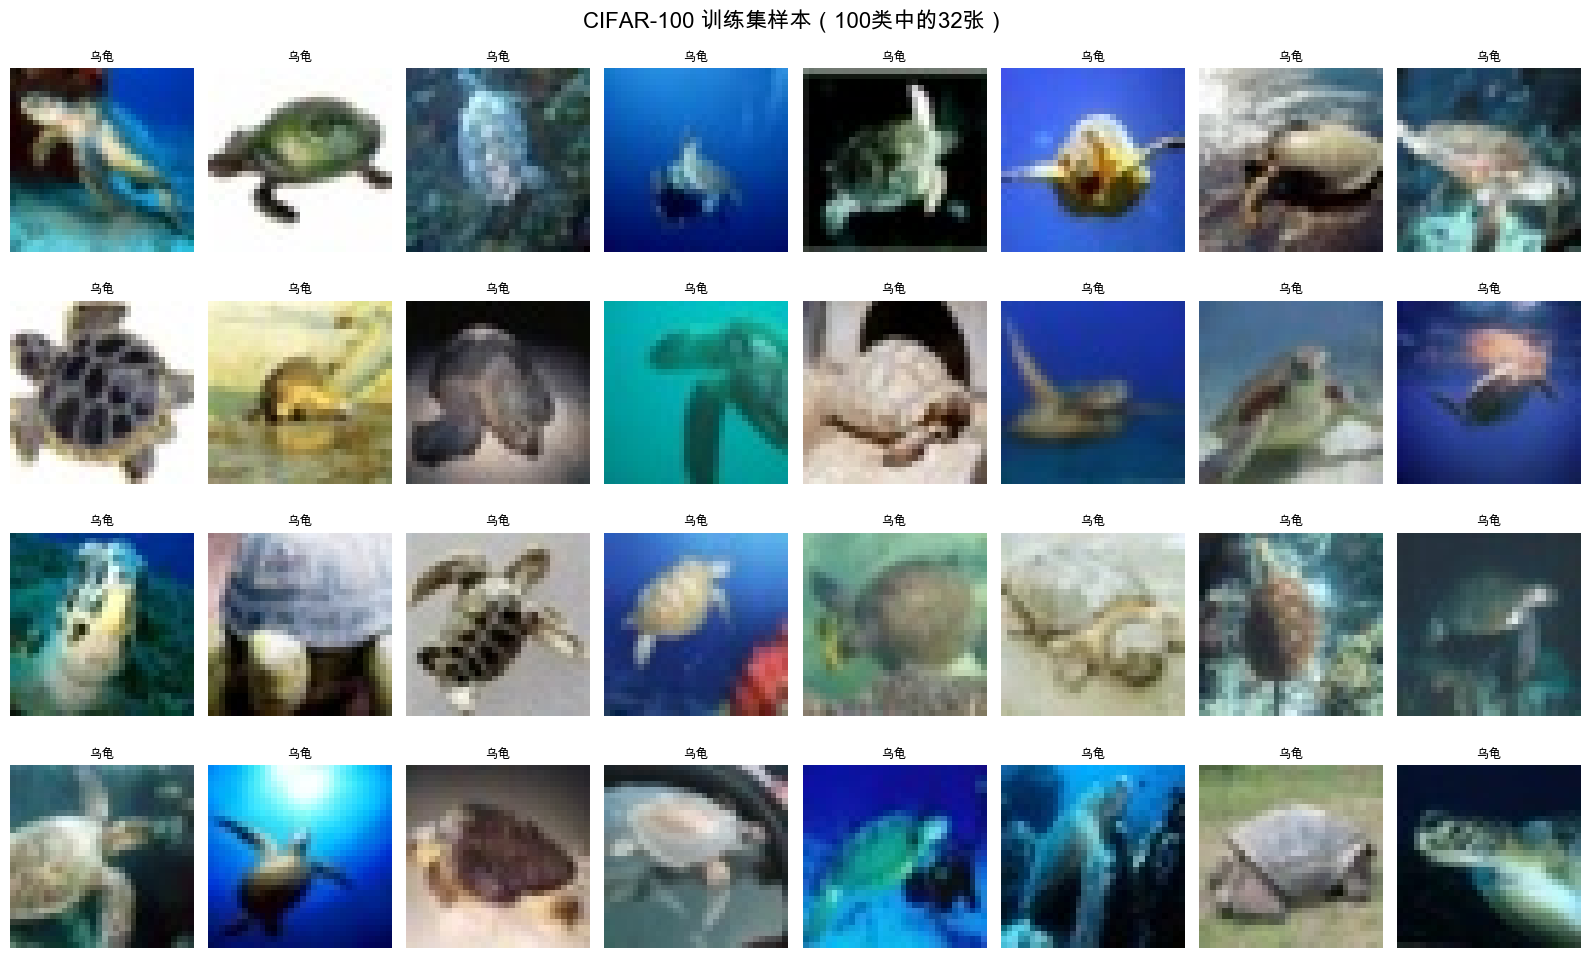

In [16]:
# 显示 4行 × 8列 = 32 张图片（从 100 类中随机展示）
fig, axes = plt.subplots(4, 8, figsize=(16, 10)) #fig是整个画布对象，axes表示格子数组对象
axes = axes.flatten() #将4*8个二维格子数组拉成一排，用.flatten()方法实现

for i in range(32):
    img, label = train_dataset[i] #拿出前32张tensor和label
    
    # 反归一化：把 [-1, 1] 还原到 [0, 1]
    img = img * 0.5 + 0.5
    
    # Tensor → numpy，调整维度 [C,H,W] → [H,W,C]
    img_np = img.numpy().transpose(1, 2, 0)
    img_np = np.clip(img_np, 0, 1)  # 裁剪防止越界
    
    axes[i].imshow(img_np) #利用numpy变为数组并且用transpose改变维度顺序，就是为了方便画图
    axes[i].set_title(class_names[label], fontsize=9)
    axes[i].axis('off')

plt.suptitle("CIFAR-100 训练集样本（100类中的32张）", fontsize=16)
plt.tight_layout()
plt.show()

---
## Cell 6：DataLoader —— 批量喂数据的"传送带"

训练时不会一张一张处理，而是**一次处理一个 batch（批次）**。

DataLoader 帮你做三件事：

| 功能 | 参数 | 为什么需要 |
|------|------|-----------|
| **打乱数据** | `shuffle=True` | 每个 epoch 随机重排，防止模型记住顺序 |
| **分批取数据** | `batch_size=64` | GPU 擅长并行处理矩阵，64 张一起算比 1 张快得多 |
| **多线程加载** | `num_workers=2` | 后台读数据不阻塞训练 |

### batch_size 怎么选？
- **太小**（如 8）：训练慢，梯度估计不准
- **太大**（如 512）：内存不够，泛化能力可能下降
- **常用值**：32 / 64 / 128 —— 你的 16GB 内存用 64 绰绰有余

In [19]:
batch_size = 64

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size, #batch size过大内存不够，影响泛化；过小训练慢，梯度估计不准确
    shuffle=True, #打乱图片
    num_workers=2 #两个线程并行？
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,        # 测试集不需要打乱
    num_workers=2
)

# 看看一个 batch 长什么样
images, labels = next(iter(train_loader)) #train_loader是一个可迭代对象，iter（）相当于给他创建书签，next用于指向下一个
#实际上用for images,labels in train_loader ：即可
"""
iterator = iter(train_loader)
batch_1 = next(iterator) # 第一批
batch_2 = next(iterator) # 第二批（不会重复取第一批）
"""

print(f"一个 batch 的图片 shape: {images.shape}")
print(f"  → [B={images.shape[0]}, C={images.shape[1]}, H={images.shape[2]}, W={images.shape[3]}]")
print(f"一个 batch 的标签 shape: {labels.shape}")
print()
print(f"这一批前 10 个标签编号: {labels[:10].tolist()}")
print(f"对应的类别名: {[class_names[l] for l in labels[:10].tolist()]}")
print()
print(f"训练集一共分成 {len(train_loader)} 个 batch")
print(f"  → {len(train_dataset)} 张图 ÷ {batch_size} = 约 {len(train_loader)} 批/epoch")
print(f"  → 训练一个 epoch = 模型看过全部 {len(train_loader)} 批数据")

"""
当你创建 train_loader 时，它只做了准备工作（记录参数），并没有把任何图片读到内存里。它的工作流发生在你开始训练循环的那一刻：

采样（Sampling）：根据 shuffle=True，它内部会生成一个打乱后的索引序列。
组装（Batching）：它会根据 batch_size=64，把索引分成若干组（比如总共 1000 张图，分成 16 组，最后一组可能不满 64 张）。
读取（Reading）：当你 for data in train_loader: 时，它才会利用 num_workers 启动子进程，根据当前批次的索引，去 train_dataset 里把对应的图片和标签取出来。
打包（Collating）：它会自动把取出来的 64 张独立图片（PIL 或 Tensor）堆叠（Stack） 成一个巨大的张量（Tensor）。
"""

一个 batch 的图片 shape: torch.Size([64, 3, 32, 32])
  → [B=64, C=3, H=32, W=32]
一个 batch 的标签 shape: torch.Size([64])

这一批前 10 个标签编号: [77, 69, 88, 74, 82, 31, 53, 73, 64, 81]
对应的类别名: ['蜜蜂', '自行车', '道路', '蛇', '衣柜', '桌子', '狼', '虫子', '碗', '蟑螂']

训练集一共分成 782 个 batch
  → 50000 张图 ÷ 64 = 约 782 批/epoch
  → 训练一个 epoch = 模型看过全部 782 批数据


'\n当你创建 train_loader 时，它只做了准备工作（记录参数），并没有把任何图片读到内存里。它的工作流发生在你开始训练循环的那一刻：\n\n采样（Sampling）：根据 shuffle=True，它内部会生成一个打乱后的索引序列。\n组装（Batching）：它会根据 batch_size=64，把索引分成若干组（比如总共 1000 张图，分成 16 组，最后一组可能不满 64 张）。\n读取（Reading）：当你 for data in train_loader: 时，它才会利用 num_workers 启动子进程，根据当前批次的索引，去 train_dataset 里把对应的图片和标签取出来。\n打包（Collating）：它会自动把取出来的 64 张独立图片（PIL 或 Tensor）堆叠（Stack） 成一个巨大的张量（Tensor）。\n'

---
## 🎉 第1步完成！

现在你应该理解了：

| ✅ | 知识点 | 一句话总结 |
|----|--------|-----------|
| ① | **CIFAR-100** | 60000 张 32×32 彩色图，分 **100 类**，每类 600 张 |
| ② | **Tensor** | PyTorch 的多维数组，shape=[B,C,H,W]，可在 GPU 运算 |
| ③ | **归一化** | ToTensor()→Normalize() 两步，把像素值拉到 [-1,1] |
| ④ | **ImageFolder** | 加载本地按类分文件夹的数据，中文名也没问题 |
| ⑤ | **DataLoader** | 自动分批 + 打乱 + 多线程加载 |
| ⑥ | **train/test 拆分** | Subset + 分层抽样，确保每类均衡 |

> 📝 **记下你不确定的地方**，跑通后我们开始搭 CNN 网络。
> CIFAR-100 有 100 个类，比 CIFAR-10 难 10 倍，模型也得更强！